In [118]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

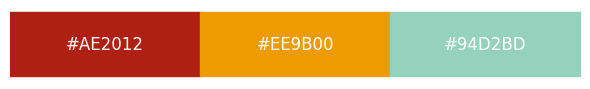

In [119]:
# Color palette
from color_palette import *
color_palette = get_color_palette(n=3)

plot_labels_colors_dict = {
    "Tethered": color_palette[0],
    "Boundary": color_palette[1],
    "Confined": color_palette[2]
}

cluster_labels_dict = {
    1: "Tethered",
    2: "Boundary",
    3: "Confined"
}
# Plot the color palette to verify
fig, ax = plt.subplots(figsize=(6, 1))
for i, color in enumerate(color_palette):
    ax.fill_between([i, i+1], 0, 1, color=color)
    ax.text(i + 0.5, 0.5, f"{color}", va='center', ha='center', color='white', fontsize=12)
ax.set_xlim(0, len(color_palette))
ax.set_yticks([])
ax.set_xticks([])

# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [120]:
# Folder of the results
results_folder = "./results/clustering_results/"
file_list = [f for f in os.listdir(results_folder) if f.endswith('.csv')]
file_list.sort()
print(f"Found {len(file_list)} result files.")
for i, file in enumerate(file_list):
    print(f"    {i}: {file}")

Found 12 result files.
    0: result_FLMRNA_1X.csv
    1: result_FLMRNA_1X_FLMRNA_2X.csv
    2: result_FLMRNA_2X.csv
    3: result_FL_2X_4EGI1.csv
    4: result_FL_2X_4EGI1_FL_2X_CHX_FL_2X_HAR_FL_2X_PURO.csv
    5: result_FL_2X_CHX.csv
    6: result_FL_2X_HAR.csv
    7: result_FL_2X_PURO.csv
    8: result_THORDELTA_1X.csv
    9: result_THORDEL_2X.csv
    10: result_THOR_1X.csv
    11: result_THOR_2X.csv


In [121]:
target_file_indices = [11, 9]
data_labels = ['isotonic', 'hypertonic']
file_list = [file_list[i] for i in target_file_indices]
print("Selected files:")
for file in file_list:
    print(f"    {file}")

Selected files:
    result_THOR_2X.csv
    result_THORDEL_2X.csv


In [122]:
file_list_base = [file.split(".")[0].split("result_")[-1] for file in file_list]

In [123]:
# Load and process each file
dfs_to_compare = []
for file in file_list:
    file_path = os.path.join(results_folder, file)
    df = pd.read_csv(file_path)
    df['Dataset'] = file.replace("result_", "").replace(".csv", "")
    dfs_to_compare.append(df)
    
dfs_to_compare[1]

,Cluster Index,Cluster Label,Cluster Rank,Color,Num Traces,Trace Indices,Dataset
0,0,Tethered,1,#AE2012,106,"[0, 3, 4, 5, 6, 8, 12, 13, 14, 15, 16, 17, 18,...",THORDEL_2X
1,2,Boundary,2,#EE9B00,34,"[2, 9, 11, 22, 25, 29, 30, 37, 41, 48, 57, 63,...",THORDEL_2X
2,1,Confined,3,#94D2BD,23,"[1, 7, 10, 20, 27, 28, 36, 39, 55, 58, 65, 89,...",THORDEL_2X


In [124]:
combined_df = pd.concat(dfs_to_compare)
labels = combined_df['Cluster Label'].unique()
combined_df

,Cluster Index,Cluster Label,Cluster Rank,Color,Num Traces,Trace Indices,Dataset
0,1,Tethered,1,#AE2012,475,"[0, 1, 3, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, ...",THOR_2X
1,0,Boundary,2,#EE9B00,222,"[2, 4, 9, 10, 12, 13, 16, 18, 20, 22, 24, 26, ...",THOR_2X
2,2,Confined,3,#94D2BD,62,"[31, 36, 37, 39, 46, 71, 103, 131, 133, 179, 1...",THOR_2X
0,0,Tethered,1,#AE2012,106,"[0, 3, 4, 5, 6, 8, 12, 13, 14, 15, 16, 17, 18,...",THORDEL_2X
1,2,Boundary,2,#EE9B00,34,"[2, 9, 11, 22, 25, 29, 30, 37, 41, 48, 57, 63,...",THORDEL_2X
2,1,Confined,3,#94D2BD,23,"[1, 7, 10, 20, 27, 28, 36, 39, 55, 58, 65, 89,...",THORDEL_2X


In [125]:
datasets = combined_df['Dataset'].unique()
datasets

array(['THOR_2X', 'THORDEL_2X'], dtype=object)

In [126]:
color = list(plot_labels_colors_dict.values())
color

['#AE2012', '#EE9B00', '#94D2BD']

/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_18869/129724481.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0)


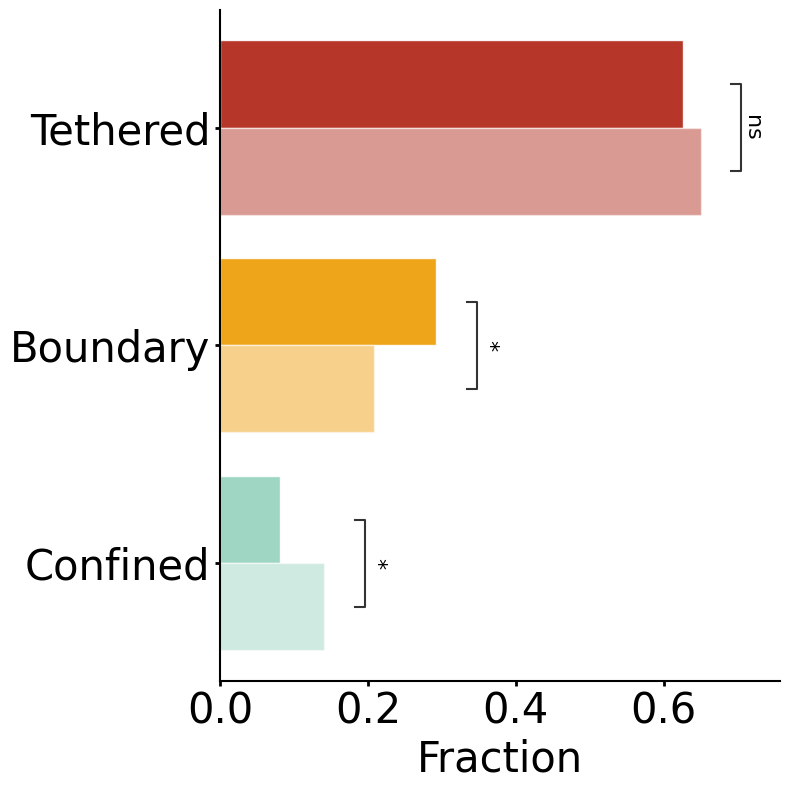

In [127]:
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import chi2_contingency
import os

# Prepare Data
# Ensure we have fractions
totals = combined_df.groupby('Dataset')['Num Traces'].sum().reset_index()
totals = totals.rename(columns={'Num Traces': 'Total'})
# Merge carefully to avoid duplicates if run multiple times
if 'Total' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Total'])
if 'Fraction' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Fraction'])
    
df_merged = pd.merge(combined_df, totals, on='Dataset')
df_merged['Fraction'] = df_merged['Num Traces'] / df_merged['Total']

# Fill missing combinations with 0 to ensure plot consistency
cluster_order = ['Tethered', 'Boundary', 'Confined']
# Retain the order set in target_file_indices
dataset_order = list(combined_df['Dataset'].unique())

# Complete the dataframe for all combinations (Cluster x Dataset) to allow proper 0 bars
import itertools
all_combos = pd.DataFrame(list(itertools.product(cluster_order, dataset_order)), columns=['Cluster Label', 'Dataset'])
df_plot = pd.merge(all_combos, df_merged, on=['Cluster Label', 'Dataset'], how='left')
df_plot['Fraction'] = df_plot['Fraction'].fillna(0)
df_plot['Num Traces'] = df_plot['Num Traces'].fillna(0)
# Fill Total for statistical calculation needs (fill with max of dataset to be safe, or recalculate)
for d in dataset_order:
    t = totals[totals['Dataset'] == d]['Total'].values
    if len(t) > 0:
        df_plot.loc[df_plot['Dataset'] == d, 'Total'] = df_plot.loc[df_plot['Dataset'] == d, 'Total'].fillna(t[0])

# Statistics
pairs = []
p_values = []
ref_dataset = dataset_order[0]

for cluster in cluster_order:
    ref_row = df_plot[(df_plot['Dataset'] == ref_dataset) & (df_plot['Cluster Label'] == cluster)]
    k_ref = int(ref_row['Num Traces'].values[0])
    n_ref = int(ref_row['Total'].values[0])
    
    for i in range(1, len(dataset_order)):
        curr_dataset = dataset_order[i]
        curr_row = df_plot[(df_plot['Dataset'] == curr_dataset) & (df_plot['Cluster Label'] == cluster)]
        k_curr = int(curr_row['Num Traces'].values[0])
        n_curr = int(curr_row['Total'].values[0])
        
        # Chi2
        # Comparison: Trace in Cluster vs Trace Not in Cluster
        obs = [[k_ref, n_ref - k_ref], [k_curr, n_curr - k_curr]]
        try:
            _, p, _, _ = chi2_contingency(obs)
        except ValueError:
            p = 1.0 # Handle cases with zero totals if any
            
        pairs.append(((cluster, ref_dataset), (cluster, curr_dataset)))
        p_values.append(p)

# Plotting
fig, ax = plt.subplots(figsize=(8, 4*len(dataset_order)))

# Use seaborn barplot
# We set a dummy palette or uniform color because we will override it
sns.barplot(data=df_plot, y='Cluster Label', x='Fraction', hue='Dataset',
            order=cluster_order, hue_order=dataset_order,
            ax=ax, edgecolor='white', palette=['grey'] * len(dataset_order), orient='h')

# Manually Recolor Bars
# Pattern: Patches are ordered by Hue. 
# First N patches = Dataset 0. Second N patches = Dataset 1.
# Where N = number of y categories (3 clusters).
n_clusters = len(cluster_order)

for i, patch in enumerate(ax.patches):
    if i >= len(dataset_order) * n_clusters:
        break
    
    dataset_idx = i // n_clusters
    cluster_idx = i % n_clusters
    
    cluster_name = cluster_order[cluster_idx]
    
    # Determine color based on Cluster
    if cluster_name in plot_labels_colors_dict:
        color = plot_labels_colors_dict[cluster_name]
    else:
        color = 'grey' # Fallback
        
    # Determine Alpha based on Dataset (fading effect)
    max_alpha = 0.9
    if dataset_idx == 0:
        alpha = max_alpha
    else:
        alpha = max_alpha / (dataset_idx + 1)
        
    patch.set_facecolor(color)
    patch.set_alpha(alpha)

# Annotations
annotator = Annotator(ax, pairs, data=df_plot, y='Cluster Label', x='Fraction', hue='Dataset',
                      order=cluster_order, hue_order=dataset_order, orient='h')
annotator.configure(test=None, loc='inside', verbose=0, fontsize=16)
annotator.set_pvalues(p_values)
annotator.annotate()

# Styling
ax.set_xlabel("Fraction", fontsize=30)
ax.set_ylabel("")
ax.tick_params(axis='both', which='major', labelsize=30)

# Rotate the y labels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ax.legend(fontsize=24, title_fontsize=26, frameon=False, loc='upper right')
ax.legend_.remove()

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set the thickness of the bottom and left spines
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
# Set the thickness of the ticks
ax.tick_params(width=2)

plt.tight_layout()
save_name = f"./results/population_comparison/vert_population_comparison_{'_'.join(file_list_base)}.svg"
os.makedirs(os.path.dirname(save_name), exist_ok=True)
plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
plt.show()


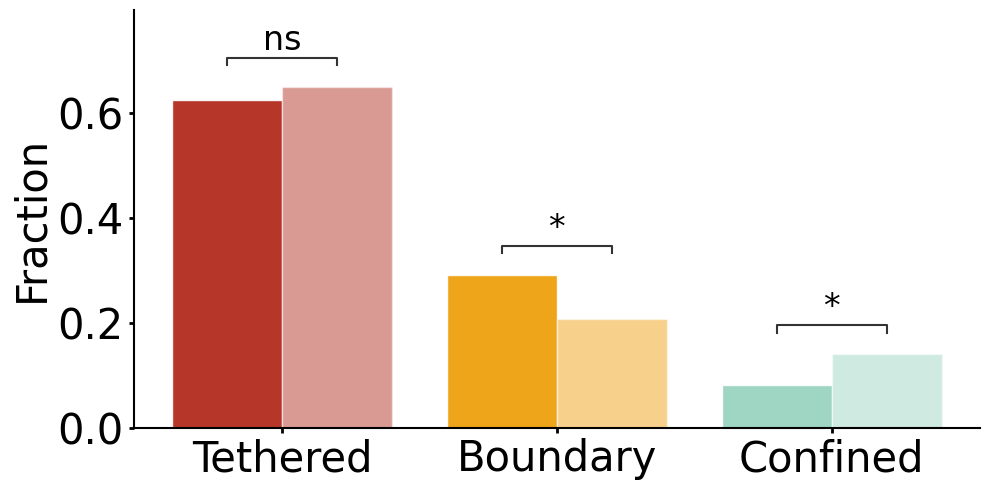

In [128]:
# Prepare Data
# Ensure we have fractions
totals = combined_df.groupby('Dataset')['Num Traces'].sum().reset_index()
totals = totals.rename(columns={'Num Traces': 'Total'})
# Merge carefully to avoid duplicates if run multiple times
if 'Total' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Total'])
if 'Fraction' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Fraction'])
    
df_merged = pd.merge(combined_df, totals, on='Dataset')
df_merged['Fraction'] = df_merged['Num Traces'] / df_merged['Total']

# Fill missing combinations with 0 to ensure plot consistency
cluster_order = ['Tethered', 'Boundary', 'Confined']

# Complete the dataframe for all combinations (Cluster x Dataset) to allow proper 0 bars
import itertools
all_combos = pd.DataFrame(list(itertools.product(cluster_order, dataset_order)), columns=['Cluster Label', 'Dataset'])
df_plot = pd.merge(all_combos, df_merged, on=['Cluster Label', 'Dataset'], how='left')
df_plot['Fraction'] = df_plot['Fraction'].fillna(0)
df_plot['Num Traces'] = df_plot['Num Traces'].fillna(0)
# Fill Total for statistical calculation needs (fill with max of dataset to be safe, or recalculate)
for d in dataset_order:
    t = totals[totals['Dataset'] == d]['Total'].values
    if len(t) > 0:
        df_plot.loc[df_plot['Dataset'] == d, 'Total'] = df_plot.loc[df_plot['Dataset'] == d, 'Total'].fillna(t[0])

# Statistics
pairs = []
p_values = []
ref_dataset = dataset_order[0]

for cluster in cluster_order:
    ref_row = df_plot[(df_plot['Dataset'] == ref_dataset) & (df_plot['Cluster Label'] == cluster)]
    k_ref = int(ref_row['Num Traces'].values[0])
    n_ref = int(ref_row['Total'].values[0])
    
    for i in range(1, len(dataset_order)):
        curr_dataset = dataset_order[i]
        curr_row = df_plot[(df_plot['Dataset'] == curr_dataset) & (df_plot['Cluster Label'] == cluster)]
        k_curr = int(curr_row['Num Traces'].values[0])
        n_curr = int(curr_row['Total'].values[0])
        
        # Chi2
        # Comparison: Trace in Cluster vs Trace Not in Cluster
        obs = [[k_ref, n_ref - k_ref], [k_curr, n_curr - k_curr]]
        try:
            _, p, _, _ = chi2_contingency(obs)
        except ValueError:
            p = 1.0 # Handle cases with zero totals if any
            
        pairs.append(((cluster, ref_dataset), (cluster, curr_dataset)))
        p_values.append(p)

# Plotting
fig, ax = plt.subplots(figsize=(5*len(dataset_order), 5))

# Use seaborn barplot
# We set a dummy palette or uniform color because we will override it
sns.barplot(data=df_plot, x='Cluster Label', y='Fraction', hue='Dataset',
            order=cluster_order, hue_order=dataset_order,
            ax=ax, edgecolor='white', palette=['grey'] * len(dataset_order))

# Manually Recolor Bars
# Pattern: Patches are ordered by Hue. 
# First N patches = Dataset 0. Second N patches = Dataset 1.
# Where N = number of x categories (3 clusters).
n_clusters = len(cluster_order)

for i, patch in enumerate(ax.patches):
    if i >= len(dataset_order) * n_clusters:
        break
    
    dataset_idx = i // n_clusters
    cluster_idx = i % n_clusters
    
    cluster_name = cluster_order[cluster_idx]
    
    # Determine color based on Cluster
    if cluster_name in plot_labels_colors_dict:
        color = plot_labels_colors_dict[cluster_name]
    else:
        color = 'grey' # Fallback
        
    # Determine Alpha based on Dataset (fading effect)
    max_alpha = 0.9
    if dataset_idx == 0:
        alpha = max_alpha
    else:
        alpha = max_alpha / (dataset_idx + 1)
        
    patch.set_facecolor(color)
    patch.set_alpha(alpha)

# Annotations
annotator = Annotator(ax, pairs, data=df_plot, x='Cluster Label', y='Fraction', hue='Dataset',
                      order=cluster_order, hue_order=dataset_order)
annotator.configure(test=None, text_format='star', loc='inside', verbose=0, fontsize=24)
annotator.set_pvalues(p_values)
annotator.annotate()

# Styling
ax.set_ylabel("Fraction", fontsize=30)
ax.set_xlabel("")
ax.tick_params(axis='both', which='major', labelsize=30)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set the thickness of the bottom and left spines
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(width=2)

ax.legend_.remove()
plt.tight_layout()
save_name = f"./results/population_comparison/hori_population_comparison_{'_'.join(file_list_base)}.svg"
os.makedirs(os.path.dirname(save_name), exist_ok=True)
plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

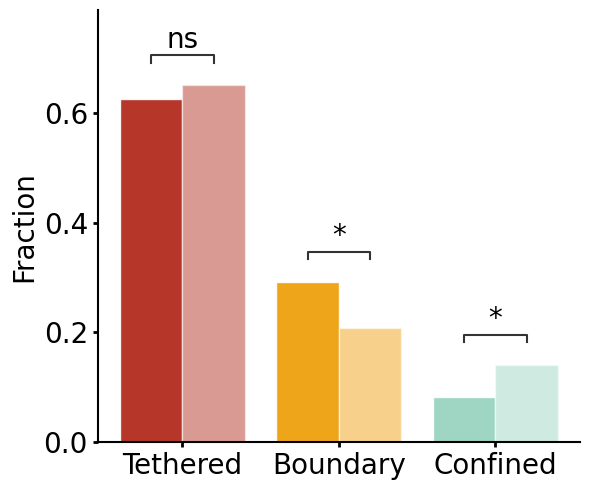

In [129]:
# Prepare Data
# Ensure we have fractions
totals = combined_df.groupby('Dataset')['Num Traces'].sum().reset_index()
totals = totals.rename(columns={'Num Traces': 'Total'})
# Merge carefully to avoid duplicates if run multiple times
if 'Total' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Total'])
if 'Fraction' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Fraction'])
    
df_merged = pd.merge(combined_df, totals, on='Dataset')
df_merged['Fraction'] = df_merged['Num Traces'] / df_merged['Total']

# Fill missing combinations with 0 to ensure plot consistency
cluster_order = ['Tethered', 'Boundary', 'Confined']
# Retain the order set in target_file_indices
dataset_order = list(combined_df['Dataset'].unique())

# Complete the dataframe for all combinations (Cluster x Dataset) to allow proper 0 bars
import itertools
all_combos = pd.DataFrame(list(itertools.product(cluster_order, dataset_order)), columns=['Cluster Label', 'Dataset'])
df_plot = pd.merge(all_combos, df_merged, on=['Cluster Label', 'Dataset'], how='left')
df_plot['Fraction'] = df_plot['Fraction'].fillna(0)
df_plot['Num Traces'] = df_plot['Num Traces'].fillna(0)
# Fill Total for statistical calculation needs (fill with max of dataset to be safe, or recalculate)
for d in dataset_order:
    t = totals[totals['Dataset'] == d]['Total'].values
    if len(t) > 0:
        df_plot.loc[df_plot['Dataset'] == d, 'Total'] = df_plot.loc[df_plot['Dataset'] == d, 'Total'].fillna(t[0])

# Statistics
pairs = []
p_values = []
ref_dataset = dataset_order[0]

for cluster in cluster_order:
    ref_row = df_plot[(df_plot['Dataset'] == ref_dataset) & (df_plot['Cluster Label'] == cluster)]
    k_ref = int(ref_row['Num Traces'].values[0])
    n_ref = int(ref_row['Total'].values[0])
    
    for i in range(1, len(dataset_order)):
        curr_dataset = dataset_order[i]
        curr_row = df_plot[(df_plot['Dataset'] == curr_dataset) & (df_plot['Cluster Label'] == cluster)]
        k_curr = int(curr_row['Num Traces'].values[0])
        n_curr = int(curr_row['Total'].values[0])
        
        # Chi2
        # Comparison: Trace in Cluster vs Trace Not in Cluster
        obs = [[k_ref, n_ref - k_ref], [k_curr, n_curr - k_curr]]
        try:
            _, p, _, _ = chi2_contingency(obs)
        except ValueError:
            p = 1.0 # Handle cases with zero totals if any
            
        pairs.append(((cluster, ref_dataset), (cluster, curr_dataset)))
        p_values.append(p)

# Plotting
fig, ax = plt.subplots(figsize=(3*len(dataset_order), 5))

# Use seaborn barplot
# We set a dummy palette or uniform color because we will override it
sns.barplot(data=df_plot, x='Cluster Label', y='Fraction', hue='Dataset',
            order=cluster_order, hue_order=dataset_order,
            ax=ax, edgecolor='white', palette=['grey'] * len(dataset_order))

# Manually Recolor Bars
# Pattern: Patches are ordered by Hue. 
# First N patches = Dataset 0. Second N patches = Dataset 1.
# Where N = number of x categories (3 clusters).
n_clusters = len(cluster_order)

for i, patch in enumerate(ax.patches):
    if i >= len(dataset_order) * n_clusters:
        break
    
    dataset_idx = i // n_clusters
    cluster_idx = i % n_clusters
    
    cluster_name = cluster_order[cluster_idx]
    
    # Determine color based on Cluster
    if cluster_name in plot_labels_colors_dict:
        color = plot_labels_colors_dict[cluster_name]
    else:
        color = 'grey' # Fallback
        
    # Determine Alpha based on Dataset (fading effect)
    max_alpha = 0.9
    if dataset_idx == 0:
        alpha = max_alpha
    else:
        alpha = max_alpha / (dataset_idx + 1)
        
    patch.set_facecolor(color)
    patch.set_alpha(alpha)

# Annotations
annotator = Annotator(ax, pairs, data=df_plot, x='Cluster Label', y='Fraction', hue='Dataset',
                      order=cluster_order, hue_order=dataset_order)
annotator.configure(test=None, loc='inside', verbose=0, fontsize=20)
annotator.set_pvalues(p_values)
annotator.annotate()

# Styling
ax.set_ylabel("Fraction", fontsize=20)
ax.set_xlabel("")
ax.tick_params(axis='both', which='major', labelsize=20)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set the thickness of the bottom and left spines
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)


ax.tick_params(width=2)

ax.legend_.remove()
plt.tight_layout()
save_name = f"./results/population_comparison/bps_hori_population_comparison_{'_'.join(file_list_base)}.svg"
os.makedirs(os.path.dirname(save_name), exist_ok=True)
plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [130]:
# Print the p-values, and number of data points for each comparison
print("Statistical Comparison Results:")
for i, pair in enumerate(pairs):
    cluster, dataset1 = pair[0]
    _, dataset2 = pair[1]
    p_value = p_values[i]
    
    # Get counts for reference and current dataset
    ref_row = df_plot[(df_plot['Dataset'] == dataset1) & (df_plot['Cluster Label'] == cluster)]
    curr_row = df_plot[(df_plot['Dataset'] == dataset2) & (df_plot['Cluster Label'] == cluster)]
    
    k_ref = int(ref_row['Num Traces'].values[0])
    n_ref = int(ref_row['Total'].values[0])
    k_curr = int(curr_row['Num Traces'].values[0])
    n_curr = int(curr_row['Total'].values[0])
    print(f"Comparison: {dataset1} vs {dataset2} for Cluster '{cluster}'")
    print(f"    p-value: {p_value:.4e}")
    print(f"    {dataset1}: {k_ref}/{n_ref} ({k_ref/n_ref:.2%})")
    print(f"    {dataset2}: {k_curr}/{n_curr} ({k_curr/n_curr:.2%})")

# Print the total number of traces for each dataset
print("\nTotal Traces per Dataset:")
for dataset in dataset_order:
    total = totals[totals['Dataset'] == dataset]['Total'].values[0]
    print(f"    {dataset}: {total} traces")

Statistical Comparison Results:
Comparison: THOR_2X vs THORDEL_2X for Cluster 'Tethered'
    p-value: 6.1844e-01
    THOR_2X: 475/759 (62.58%)
    THORDEL_2X: 106/163 (65.03%)
Comparison: THOR_2X vs THORDEL_2X for Cluster 'Boundary'
    p-value: 3.8100e-02
    THOR_2X: 222/759 (29.25%)
    THORDEL_2X: 34/163 (20.86%)
Comparison: THOR_2X vs THORDEL_2X for Cluster 'Confined'
    p-value: 2.5750e-02
    THOR_2X: 62/759 (8.17%)
    THORDEL_2X: 23/163 (14.11%)

Total Traces per Dataset:
    THOR_2X: 759 traces
    THORDEL_2X: 163 traces
